# Second Harmonic Generation (SHG) Analysis Tutorial — Starch

## Comprehensive Polarization-Resolved SHG Microscopy Analysis

This tutorial provides a **step-by-step guide** to analyzing polarization-resolved
Second Harmonic Generation (SHG) microscopy data from **starch granules**.

### Workflow
1. **Load** 37 TIFF images acquired at polarization angles 0° → 360° (10° steps)
2. **Define** the SHG intensity model for starch
3. **Fit** the model to a single pixel (quick verification)
4. **Extend** fitting to every pixel in the image
5. **Visualize** results: φ colormap, parameter histograms, polar plots, R² map

### SHG Model

$$I_{SHG}(\alpha) = E \Big( \sin^2\!\big(2(\varphi - \alpha)\big) + \big[ A\,\sin\!\big(2(\varphi - \alpha)\big) + B\,\cos\!\big(2(\varphi - \alpha)\big) \big]^2 \Big)$$

| Parameter | Description |
|-----------|-------------|
| $E$ | Scaling factor (proportional to signal intensity) |
| $A$ | Susceptibility ratio parameter |
| $B$ | Susceptibility ratio parameter |
| $\varphi$ | Phase angle — molecular orientation (radians) |
| $\alpha$ | Polarization angle of incident light (known) |

**Post-processing rule:** if $A > B$ after fitting, swap $A \leftrightarrow B$ and set $\varphi \to \varphi + \pi/2$.

---
## 1. Setup — Install Dependencies

In [4]:
import subprocess, sys

for pkg in ['numpy', 'scipy', 'matplotlib', 'tifffile', 'tqdm']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import tifffile
from pathlib import Path
from tqdm import tqdm
import tkinter as tk
from tkinter import font
import warnings

warnings.filterwarnings('ignore')

#  ============================================================
#  Pesronal preference for good quality plots
#  ============================================================

plt.rcParams.update({
    'figure.figsize': (10, 7),
    'figure.dpi': 120,
    'font.size': 12,
    'font.family': 'Times New Roman',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
})

# Library check
print("✅ Libraries imported")

✅ Libraries imported


---
## 2. Configuration

Modify `DATA_DIR` if your TIFF files are in a different folder.

In [10]:
# ============================================================
# CONFIGURATION — adjust as needed
# ============================================================

# GUI folder picker

import tkinter as tk
from tkinter import filedialog as fd
_root = tk.Tk()
_root.withdraw()                    # hide the blank Tk window
_root.attributes('-topmost', True)  # dialog appears on top
_chosen = fd.askdirectory(title='Select folder with TIFF files')
_root.destroy()

ALPHA_DEG = np.arange(0, 370, 10, dtype=float)
ALPHA_RAD = np.deg2rad(ALPHA_DEG)
N_FRAMES  = 37

# Curve-fit initial guesses  (E, A, B, phi)
P0     = [10_000.0, 1.0, 5.0, np.pi / 4]
BOUNDS = ([0, 0, 0, 0], [100_000, 5, 10, np.pi / 2])

print(f"📂 Data dir      : {DATA_DIR.resolve()}")
print(f"📐 Polarization  : {ALPHA_DEG[0]:.0f}° → {ALPHA_DEG[-1]:.0f}°  (step {ALPHA_DEG[1]-ALPHA_DEG[0]:.0f}°, {len(ALPHA_DEG)} frames)")
print(f"🎯 Initial guess : E={P0[0]:.0f}, A={P0[1]}, B={P0[2]}, φ={P0[3]:.4f} rad ({np.rad2deg(P0[3]):.1f}°)")
print(f"📏 Bounds (lo)   : {BOUNDS[0]}")
print(f"📏 Bounds (hi)   : {BOUNDS[1]}")

📂 Data dir      : C:\Users\user\Desktop\Shg_analysis_training\Samples\Starch\tif1renamed
📐 Polarization  : 0° → 360°  (step 10°, 37 frames)
🎯 Initial guess : E=10000, A=1.0, B=5.0, φ=0.7854 rad (45.0°)
📏 Bounds (lo)   : [0, 0, 0, 0]
📏 Bounds (hi)   : [100000, 5, 10, 1.5707963267948966]


---
## 3. Data Loading

Load all TIFF files into a 3-D array `(frames, height, width)`.

In [11]:
tif_files = sorted(DATA_DIR.glob("*.tif"))
print(f"Found {len(tif_files)} TIFF files")
assert len(tif_files) == N_FRAMES, f"Expected {N_FRAMES}, found {len(tif_files)}"

stack = np.array([tifffile.imread(str(f)) for f in tif_files], dtype=float)
mean_image = np.mean(stack, axis=0)

print(f"\nStack shape       : {stack.shape}  (frames, H, W)")
print(f"Original dtype    : {tifffile.imread(str(tif_files[0])).dtype}")
print(f"Intensity range   : [{stack.min():.0f}, {stack.max():.0f}]")
print(f"Mean intensity    : {stack.mean():.1f}")

Found 37 TIFF files

Stack shape       : (37, 500, 500)  (frames, H, W)
Original dtype    : uint16
Intensity range   : [0, 65535]
Mean intensity    : 3228.8


---
## 4. Data Exploration

Sample frames at key angles and a consistency check (0° vs 360°).

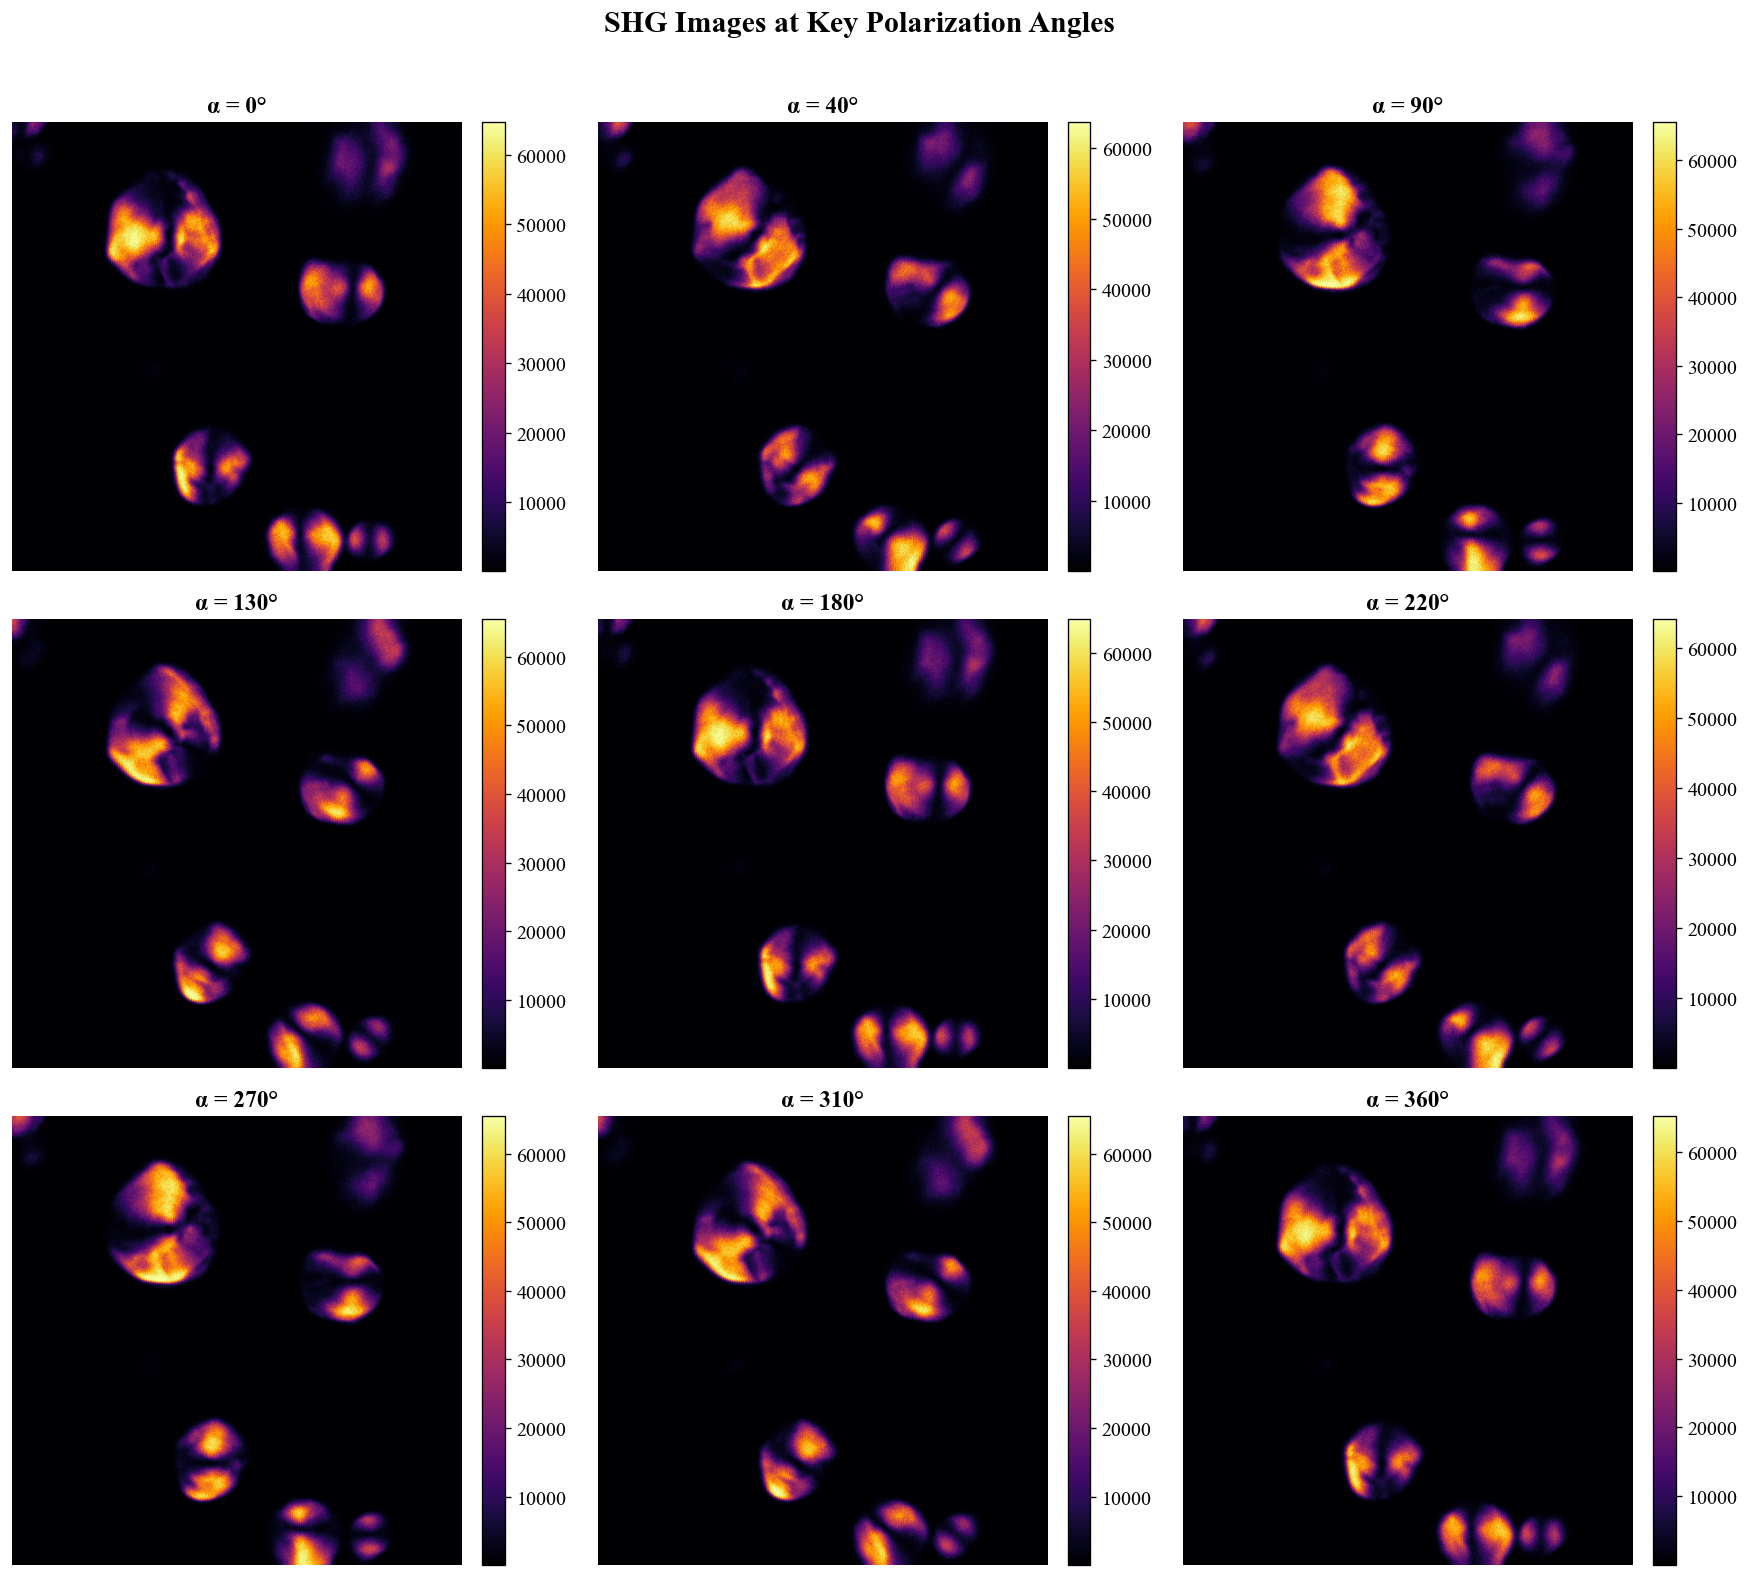

In [8]:
key_angles  = [0, 45, 90, 135, 180, 225, 270, 315, 360]
key_indices = [int(a / 10) for a in key_angles]

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for ax, idx in zip(axes.flat, key_indices):
    im = ax.imshow(stack[idx], cmap='inferno')
    ax.set_title(f"α = {ALPHA_DEG[idx]:.0f}°", fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, format='%.0f')
fig.suptitle("SHG Images at Key Polarization Angles",
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0];  im = ax.imshow(mean_image, cmap='inferno')
ax.set_title("Mean image", fontweight='bold'); ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Intensity")

ax = axes[1];  im = ax.imshow(stack[0], cmap='inferno')
ax.set_title("α = 0°", fontweight='bold'); ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[2];  im = ax.imshow(stack[-1], cmap='inferno')
ax.set_title("α = 360°", fontweight='bold'); ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Consistency check: 0° and 360° should be nearly identical",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

diff = np.abs(stack[0] - stack[-1])
print(f"Max  |I(0°) − I(360°)| = {diff.max():.1f}")
print(f"Mean |I(0°) − I(360°)| = {diff.mean():.2f}")

---
## 5. SHG Model Definition

$$I_{SHG}(\alpha) = E \Big( \sin^2\!\big(2(\varphi - \alpha)\big) + \big[ A\sin\!\big(2(\varphi - \alpha)\big) + B\cos\!\big(2(\varphi - \alpha)\big) \big]^2 \Big)$$

In [ ]:
def shg_model(alpha, E, A, B, phi):
    """
    SHG intensity model for starch.

    Parameters
    ----------
    alpha : array_like   Polarization angle (rad) — independent variable.
    E     : float        Scaling factor.
    A     : float        Susceptibility ratio parameter.
    B     : float        Susceptibility ratio parameter.
    phi   : float        Phase / molecular orientation (rad).

    Returns
    -------
    I_shg : array_like   Predicted SHG intensity.
    """
    d = 2.0 * (phi - alpha)
    s = np.sin(d)
    c = np.cos(d)
    return E * (s**2 + (A * s + B * c)**2)

print("✅ shg_model() defined")

In [ ]:
# Verify model shape with initial-guess parameters
alpha_fine = np.linspace(0, 2 * np.pi, 720)
I_test = shg_model(alpha_fine, *P0)

fig = plt.figure(figsize=(16, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(np.rad2deg(alpha_fine), I_test, 'b-', lw=2)
ax1.set_xlabel("α (°)"); ax1.set_ylabel("Intensity (a.u.)")
ax1.set_title("Cartesian — initial-guess params"); ax1.set_xlim(0, 360)

ax2 = fig.add_subplot(1, 2, 2, projection='polar')
ax2.plot(alpha_fine, I_test, 'b-', lw=2)
ax2.set_title("Polar — initial-guess params", pad=20)

fig.suptitle(f"E={P0[0]:.0f}, A={P0[1]}, B={P0[2]}, φ={np.rad2deg(P0[3]):.1f}°",
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

### 5.1 Understanding the Model Terms

The model encodes how starch’s nonlinear optical response depends on polarization:

| Term | Expression | Physical Meaning |
|------|-----------|------------------|
| **Baseline** | $\sin^2(2(\varphi - \alpha))$ | Off-diagonal susceptibility tensor elements. Produces the characteristic **four-lobed** polar pattern. |
| **Modulation** | $[A\sin(\cdot) + B\cos(\cdot)]^2$ | Ratio of diagonal to off-diagonal susceptibility components. $A$ and $B$ encode different tensor ratios. |
| **Phase $\varphi$** | Orientation angle | Direction of crystalline molecular chains. Mapping $\varphi$ reveals the **radial organization** of amylopectin in the starch granule. |
| **Scale $E$** | Amplitude factor | Proportional to squared incident field and overall nonlinear susceptibility magnitude. |

> **Why swap when $A > B$?** The model has a symmetry: swapping $A \leftrightarrow B$ and shifting
> $\varphi$ by $\pi/2$ yields the same curve. The convention $A \leq B$ removes this
> degeneracy so that $\varphi$ consistently encodes the physical orientation.

In [ ]:
# Parameter sensitivity: how each parameter reshapes the SHG curve
alpha_s = np.linspace(0, 2 * np.pi, 360)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- E (scaling) ---
ax = axes[0, 0]
for Ev in [2000, 5000, 10000, 30000]:
    ax.plot(np.rad2deg(alpha_s), shg_model(alpha_s, Ev, 1, 5, np.pi/4),
            lw=2, label=f'E={Ev:,}')
ax.set_title("Effect of E (scaling)", fontweight='bold')
ax.set_xlabel("α (°)"); ax.set_ylabel("Intensity"); ax.legend()

# --- A ---
ax = axes[0, 1]
for Av in [0.2, 0.5, 1.0, 3.0]:
    ax.plot(np.rad2deg(alpha_s), shg_model(alpha_s, 10000, Av, 5, np.pi/4),
            lw=2, label=f'A={Av}')
ax.set_title("Effect of A", fontweight='bold')
ax.set_xlabel("α (°)"); ax.set_ylabel("Intensity"); ax.legend()

# --- B ---
ax = axes[1, 0]
for Bv in [1, 3, 5, 9]:
    ax.plot(np.rad2deg(alpha_s), shg_model(alpha_s, 10000, 1, Bv, np.pi/4),
            lw=2, label=f'B={Bv}')
ax.set_title("Effect of B", fontweight='bold')
ax.set_xlabel("α (°)"); ax.set_ylabel("Intensity"); ax.legend()

# --- phi (orientation) ---
ax = axes[1, 1]
for pv in [0, np.pi/6, np.pi/4, np.pi/3, np.pi/2]:
    ax.plot(np.rad2deg(alpha_s), shg_model(alpha_s, 10000, 1, 5, pv),
            lw=2, label=f'φ={np.rad2deg(pv):.0f}°')
ax.set_title("Effect of φ (orientation)", fontweight='bold')
ax.set_xlabel("α (°)"); ax.set_ylabel("Intensity"); ax.legend()

fig.suptitle("Parameter Sensitivity Analysis\n"
             "Each panel varies one parameter while others stay at initial-guess values",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Single-Pixel Analysis — Quick Verification

Before the full-image run, we verify the fitting on **one pixel** with strong signal.

In [ ]:
# Auto-select pixel with highest mean intensity
py, px = np.unravel_index(np.argmax(mean_image), mean_image.shape)
# ▶ Override manually if desired:
# py, px = 250, 250

print(f"🎯 Selected pixel : (row={py}, col={px})")
print(f"   Mean intensity : {mean_image[py, px]:.1f}")

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(mean_image, cmap='inferno')
ax.plot(px, py, 'c+', ms=20, mew=3, label=f'pixel ({py}, {px})')
ax.set_title("Pixel location on mean image", fontweight='bold')
ax.legend(fontsize=11); ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# Extract polarization series
pixel_data = stack[:, py, px]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ALPHA_DEG, pixel_data, 'ko-', ms=7, lw=1.5,
        markerfacecolor='dodgerblue', label='Data')
ax.set_xlabel("α (°)"); ax.set_ylabel("SHG Intensity (a.u.)")
ax.set_title(f"Raw data — pixel ({py}, {px})", fontweight='bold')
ax.set_xlim(-5, 365); ax.set_xticks(np.arange(0, 361, 45))
ax.legend(); plt.tight_layout(); plt.show()
print(f"Range: [{pixel_data.min():.0f}, {pixel_data.max():.0f}]   Mean: {pixel_data.mean():.1f}")

### 6.1 Curve Fit — Single Pixel

Using `scipy.optimize.curve_fit` with **bounded least squares**.

In [ ]:
try:
    popt, pcov = curve_fit(shg_model, ALPHA_RAD, pixel_data,
                           p0=P0, bounds=BOUNDS, maxfev=20000)

    E_fit, A_fit, B_fit, phi_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # Post-processing: if A > B  →  swap & adjust phi
    swapped = False
    if A_fit > B_fit:
        A_fit, B_fit = B_fit, A_fit
        phi_fit += np.pi / 2
        perr[1], perr[2] = perr[2], perr[1]
        swapped = True

    # R²
    y_pred  = shg_model(ALPHA_RAD, E_fit, A_fit, B_fit, phi_fit)
    ss_res  = np.sum((pixel_data - y_pred)**2)
    ss_tot  = np.sum((pixel_data - pixel_data.mean())**2)
    r2      = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    print("=" * 55)
    print(f"  FIT RESULTS — pixel ({py}, {px})")
    print("=" * 55)
    print(f"  E   = {E_fit:12.2f}  ± {perr[0]:.2f}")
    print(f"  A   = {A_fit:12.4f}  ± {perr[1]:.4f}")
    print(f"  B   = {B_fit:12.4f}  ± {perr[2]:.4f}")
    print(f"  φ   = {phi_fit:12.4f} rad = {np.rad2deg(phi_fit):.2f}°  ± {np.rad2deg(perr[3]):.2f}°")
    print("-" * 55)
    print(f"  R²  = {r2:.6f}")
    print(f"  RSS = {ss_res:.2f}")
    if swapped:
        print("  ⚠ A > B → swapped A↔B, φ → φ + π/2")
    print("=" * 55)

except RuntimeError as e:
    print(f"❌ Fitting failed: {e}")

### 6.2 Visualization — Polar, Cartesian & Residuals

In [ ]:
alpha_fine  = np.linspace(0, 2 * np.pi, 720)
I_fit_fine  = shg_model(alpha_fine, E_fit, A_fit, B_fit, phi_fit)

fig = plt.figure(figsize=(18, 5.5))

# -- Polar --
ax1 = fig.add_subplot(1, 3, 1, projection='polar')
ax1.plot(ALPHA_RAD, pixel_data, 'ko', ms=5, label='Data', zorder=5)
ax1.plot(alpha_fine, I_fit_fine, 'r-', lw=2, label='Fit', zorder=4)
ax1.set_title(f"Polar — R²={r2:.4f}", pad=20, fontweight='bold')
ax1.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

# -- Cartesian --
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(ALPHA_DEG, pixel_data, 'ko', ms=6, label='Data')
ax2.plot(np.rad2deg(alpha_fine), I_fit_fine, 'r-', lw=2, label='Fit')
ax2.set_xlabel("α (°)"); ax2.set_ylabel("Intensity")
ax2.set_title("Cartesian fit", fontweight='bold')
ax2.set_xlim(-5, 365); ax2.set_xticks(np.arange(0, 361, 45))
ax2.legend()

# -- Residuals --
ax3 = fig.add_subplot(1, 3, 3)
residuals = pixel_data - shg_model(ALPHA_RAD, E_fit, A_fit, B_fit, phi_fit)
ax3.stem(ALPHA_DEG, residuals, linefmt='C0-', markerfmt='C0o', basefmt='k-')
ax3.axhline(0, color='red', ls='--', alpha=0.5)
ax3.set_xlabel("α (°)"); ax3.set_ylabel("Residual")
ax3.set_title("Residuals (Data − Fit)", fontweight='bold')
ax3.set_xlim(-5, 365); ax3.set_xticks(np.arange(0, 361, 45))

plt.tight_layout(); plt.show()

---
## 7. Full-Image Analysis — Pixel-by-Pixel Fitting

We now run the curve fit on **every pixel** above a minimum intensity threshold.

> ⚠️ **Performance note**: this may take several minutes for large images.
> A progress bar is shown below.

In [ ]:
def fit_pixel(intensities, alpha_rad, p0, bounds):
    """Fit the SHG model to one pixel. Returns (params, r2) or (None, NaN)."""
    try:
        popt, _ = curve_fit(shg_model, alpha_rad, intensities,
                            p0=p0, bounds=bounds, maxfev=20000)
        E, A, B, phi = popt

        if A > B:
            A, B = B, A
            phi += np.pi / 2

        y_pred = shg_model(alpha_rad, E, A, B, phi)
        ss_res = np.sum((intensities - y_pred)**2)
        ss_tot = np.sum((intensities - intensities.mean())**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        return (E, A, B, phi), r2
    except (RuntimeError, ValueError):
        return None, np.nan

print("✅ fit_pixel() defined")

In [ ]:
n_frames, height, width = stack.shape
total_px = height * width

# Parameter maps (NaN = not fitted)
E_map   = np.full((height, width), np.nan)
A_map   = np.full((height, width), np.nan)
B_map   = np.full((height, width), np.nan)
phi_map = np.full((height, width), np.nan)
r2_map  = np.full((height, width), np.nan)

# Threshold: skip background (lowest 5 % of max)
threshold   = 0.05 * mean_image.max()
signal_mask = mean_image > threshold
n_to_fit    = int(np.sum(signal_mask))

print(f"Image         : {height} × {width} = {total_px:,} px")
print(f"Threshold     : {threshold:.1f}  (5 % of max)")
print(f"Pixels to fit : {n_to_fit:,}  ({100*n_to_fit/total_px:.1f} %)")

ok = 0; fail = 0
for y in tqdm(range(height), desc="Fitting rows", unit="row"):
    for x in range(width):
        if not signal_mask[y, x]:
            continue
        params, r2 = fit_pixel(stack[:, y, x], ALPHA_RAD, P0, BOUNDS)
        if params is not None:
            E_map[y, x], A_map[y, x], B_map[y, x], phi_map[y, x] = params
            r2_map[y, x] = r2
            ok += 1
        else:
            fail += 1

print(f"\n{'='*50}")
print(f"  ✅ Successful : {ok:,}")
print(f"  ❌ Failed     : {fail:,}")
print(f"  ⬛ Background : {total_px - n_to_fit:,}")
print(f"{'='*50}")

---
## 8. Results Visualization

### 8.1 Phase (φ) Colormap

$\varphi$ encodes the **molecular orientation**. The HSV colorscale is used because it naturally
wraps for angular data.

In [ ]:
phi_deg = np.rad2deg(phi_map)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax = axes[0]
im = ax.imshow(phi_deg, cmap='hsv', vmin=0, vmax=180, interpolation='nearest')
ax.set_title("φ (degrees)", fontweight='bold'); ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="φ (°)")

ax = axes[1]
ax.imshow(mean_image, cmap='gray', alpha=0.6)
masked = np.ma.masked_where(np.isnan(phi_deg), phi_deg)
im = ax.imshow(masked, cmap='hsv', vmin=0, vmax=180, alpha=0.75, interpolation='nearest')
ax.set_title("φ overlay on mean image", fontweight='bold'); ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="φ (°)")

ax = axes[2]
im = ax.imshow(mean_image, cmap='inferno')
ax.set_title("Mean image (ref)", fontweight='bold'); ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Intensity")

fig.suptitle("Phase Orientation Map — SHG Curve Fitting",
             fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

### 8.2 Parameter Histograms

In [ ]:
valid = ~np.isnan(E_map)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (data, name, color, fmt) in zip(axes.flat, [
    (E_map[valid],              "E (scaling)",  'steelblue',    '.1f'),
    (A_map[valid],              "A",            'coral',        '.4f'),
    (B_map[valid],              "B",            'mediumseagreen','.4f'),
    (np.rad2deg(phi_map[valid]),"φ (°)", 'mediumpurple', '.1f'),
]):
    mu, sigma = np.mean(data), np.std(data)
    ax.hist(data, bins=100, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(mu, color='red', ls='--', lw=2, label=f'Mean: {mu:{fmt}}')
    ax.set_xlabel(name); ax.set_ylabel("Count")
    ax.set_title(f"{name}   (μ={mu:{fmt}}, σ={sigma:{fmt}})", fontweight='bold')
    ax.legend()

fig.suptitle("Parameter Distributions — SHG Curve Fitting",
             fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

### 8.3 R² Quality Map

| R² range | Interpretation |
|-----------|---------------|
| > 0.95 | Excellent |
| 0.90 – 0.95 | Good |
| 0.80 – 0.90 | Acceptable |
| < 0.80 | Poor — model may not apply |

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
im = ax.imshow(r2_map, cmap='RdYlGn', vmin=0, vmax=1, interpolation='nearest')
ax.set_title("R² Map — Fit Quality", fontweight='bold'); ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="R²")

ax = axes[1]
r2v = r2_map[~np.isnan(r2_map)]
ax.hist(r2v, bins=100, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(r2v),   color='red',    ls='--', lw=2, label=f'Mean: {np.mean(r2v):.4f}')
ax.axvline(np.median(r2v), color='orange',  ls=':',  lw=2, label=f'Median: {np.median(r2v):.4f}')
ax.axvline(0.90,           color='green',   ls='-.', lw=2, label='R² = 0.90')
ax.set_xlabel("R²"); ax.set_ylabel("Count")
ax.set_title("R² Distribution", fontweight='bold'); ax.legend()

fig.suptitle("Fit Quality Assessment", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

n = len(r2v)
for t in [0.99, 0.95, 0.90, 0.80]:
    k = int(np.sum(r2v > t))
    print(f"  R² > {t:.2f} : {k:6,} / {n:,}  ({100*k/n:5.1f} %)")

### 8.4 Pixel Explorer

After the full-image fit, use `explore_pixel(row, col)` to inspect **any pixel’s**
fit and parameters. Modify the coordinates below to explore different regions.

In [ ]:
def explore_pixel(row, col):
    """Show the SHG fit for any pixel after full-image analysis."""
    if np.isnan(E_map[row, col]):
        print(f"⚠ Pixel ({row}, {col}) was not fitted (background or failed)")
        return

    E_px, A_px   = E_map[row, col], A_map[row, col]
    B_px, phi_px = B_map[row, col], phi_map[row, col]
    r2_px        = r2_map[row, col]
    pix          = stack[:, row, col]

    af = np.linspace(0, 2 * np.pi, 720)
    If = shg_model(af, E_px, A_px, B_px, phi_px)

    fig = plt.figure(figsize=(16, 5))

    ax1 = fig.add_subplot(1, 3, 1, projection='polar')
    ax1.plot(ALPHA_RAD, pix, 'ko', ms=5, label='Data', zorder=5)
    ax1.plot(af, If, 'r-', lw=2, label='Fit', zorder=4)
    ax1.set_title(f"Pixel ({row}, {col})\nR²={r2_px:.4f}", pad=20, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.3, 1.1))

    ax2 = fig.add_subplot(1, 3, 2)
    ax2.plot(ALPHA_DEG, pix, 'ko', ms=6, label='Data')
    ax2.plot(np.rad2deg(af), If, 'r-', lw=2, label='Fit')
    ax2.set_xlabel("α (°)"); ax2.set_ylabel("Intensity")
    ax2.set_title("Cartesian fit", fontweight='bold')
    ax2.set_xlim(-5, 365); ax2.set_xticks(np.arange(0, 361, 45))
    ax2.legend()

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.imshow(np.rad2deg(phi_map), cmap='hsv', vmin=0, vmax=180)
    ax3.plot(col, row, 'c+', ms=20, mew=3)
    ax3.set_title("Location on φ map", fontweight='bold')
    ax3.axis('off')

    plt.tight_layout(); plt.show()
    print(f"E={E_px:.2f}  A={A_px:.4f}  B={B_px:.4f}  "
          f"φ={phi_px:.4f} rad ({np.rad2deg(phi_px):.1f}°)  R²={r2_px:.4f}")

# ▶ Change coordinates to explore different pixels:
explore_pixel(height // 2, width // 2)

---
## 9. Save Results

In [ ]:
out = Path("results"); out.mkdir(exist_ok=True)

for name, arr in [("E_map", E_map), ("A_map", A_map), ("B_map", B_map),
                  ("phi_map", phi_map), ("r2_map", r2_map), ("signal_mask", signal_mask)]:
    np.save(out / f"{name}.npy", arr)

print(f"✅ Parameter maps saved to {out.resolve()}")

---
## 10. Summary

| Step | Description |
|------|-------------|
| **Data** | 37 TIFF frames, 0° → 360°, 10° steps |
| **Model** | $I_{SHG} = E\big(\sin^2(2(\varphi-\alpha)) + [A\sin(2(\varphi-\alpha))+B\cos(2(\varphi-\alpha))]^2\big)$ |
| **Single pixel** | Verified fit on one pixel before full run |
| **Full image** | Pixel-by-pixel `curve_fit` (bounded least squares) |
| **Outputs** | φ colormap, parameter histograms, R² map |

### Key points
- Initial guesses $(E,A,B,\varphi) = (10\,000,\;1,\;5,\;\pi/4)$
- Bounds: $E\in[0,10^5]$, $A\in[0,5]$, $B\in[0,10]$, $\varphi\in[0,\pi/2]$
- Post-processing: if $A>B$ swap and $\varphi\to\varphi+\pi/2$
- R² map gives spatial fit-quality overview